<h3 style="color :blue;">Inventory Management and Safety stock Optimization</h3>
<h4 style="color :blue;">Objective</h4>
<p style="font-size:30px;color:black;">To develop a data-driven inventory management system that optimizes inventory levels and safety stock by analyzing demand patterns. The project aims to reduce stockouts and excess inventory while improving product availability and operational efficiency.</p>
<h4 style="color :blue;">Problem Statement</h4>
<p style="font-size:30px;color:black;">Business often face difficulities in maintaining the right balance between product availability and inventory holding costs. Excess inventory increases storage and holding cost. while insufficient inventory leads to stockouts and lost sales. This project focuses on analyzing inventory and demand-related data to identify demand variability,optimize afety stock levels, and support better inventory planning decisions through data analysis.</p>

In [1]:
#import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

In [2]:
# read the csv file
df=pd.read_csv("temp.csv")
df.head()

,Date,Store Id,Product Id,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195.0,102.0,252.0,72.72,5.0,Snowy,0.0,85.73,Winter,0.0,115.0
1,2022-01-01,S001,P0002,Clothing,North,117.0,117.0,249.0,80.16,15.0,Snowy,1.0,92.02,Winter,0.0,229.0
2,2022-01-01,S001,P0003,Clothing,North,247.0,114.0,612.0,62.94,10.0,Snowy,1.0,60.08,Winter,0.0,157.0
3,2022-01-01,S001,P0004,Electronics,North,139.0,45.0,102.0,87.63,10.0,Snowy,0.0,85.19,Winter,0.0,52.0
4,2022-01-01,S001,P0005,Groceries,North,152.0,65.0,271.0,54.41,0.0,Snowy,0.0,51.63,Winter,0.0,59.0


In [3]:
# clean the date column
df['Date']=df['Date'].str.replace('\n','',regex=False).str.strip()

In [4]:
# changing the date datatype
df['Date']=pd.to_datetime(df['Date'])

In [5]:
df['Date'].dtype

dtype('<M8[ns]')

In [6]:
# check the nulls
df.isnull().sum()

Date                  0
Store Id              0
Product Id            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Weather Condition     0
Promotion             0
Competitor Pricing    0
Seasonality           0
Epidemic              0
Demand                0
dtype: int64

In [7]:
# check the duplicates
df.duplicated().sum()

np.int64(0)

In [8]:
df=df.sort_values(by='Date')

In [9]:
df['Date'].value_counts()

Date
2022-01-02    103
2023-06-07    100
2023-05-17    100
2023-05-18    100
2023-05-19    100
             ... 
2022-09-13    100
2022-09-14    100
2022-09-15    100
2022-09-16    100
2024-01-30    100
Name: count, Length: 760, dtype: int64

In [10]:
# set date column as index
df=df.set_index('Date')

In [11]:
# grouping the deamand.
daily_demand=df.groupby('Date')['Demand'].sum()

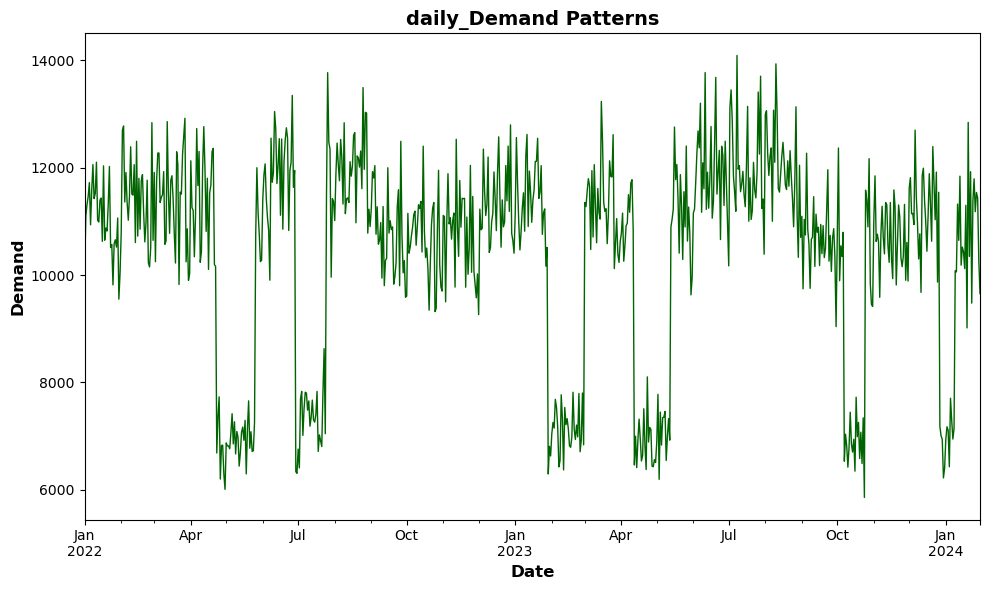

In [12]:
# plotting the daily demand patterns
plt.figure(figsize=(10,6))
daily_demand.plot(kind='line',color='darkgreen',linewidth=1)
plt.title('daily_Demand Patterns',fontsize=14,fontweight='bold',color='black')
plt.xlabel('Date',fontsize=12,fontweight='bold')
plt.ylabel('Demand',fontsize=12,fontweight='bold')
plt.tight_layout()
plt.show()

<h3 style="color :blue;">Observations</h3>
<p style="font-size:30px;color:black;">As we have more data of same days,we grouped the days and calculated the demand per each day.<br>1.There is no clear upward or downward trend.but the demand frequently spikes near 14,000<br>2.Notable peeks occured around August 2022,July/August 2023 <br>3.The demand is mostly dropped during early 2023<br>4.The demand is raising in May in both the years.</p>

In [13]:
# let's zoom it and group the dates by months. and check the demand patterns
monthly_demand=df['Demand'].resample('ME').sum()

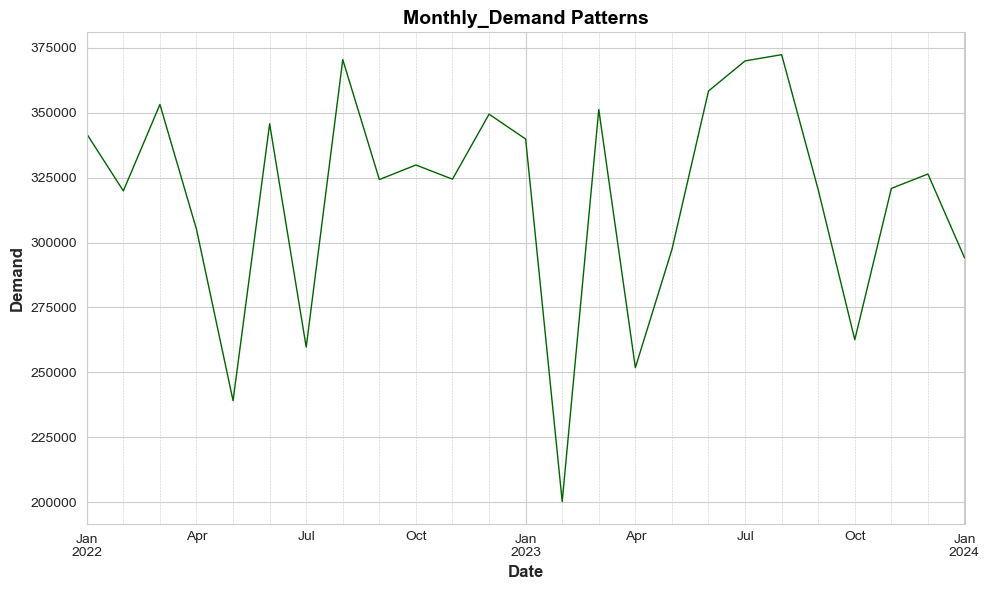

In [14]:
# plotting the monthly demand patterns
sns.set_style('whitegrid')
plt.figure(figsize=(10,6))
monthly_demand.plot(kind='line',color='darkgreen',linewidth=1)
plt.title('Monthly_Demand Patterns',fontsize=14,fontweight='bold',color='black')
plt.xlabel('Date',fontsize=12,fontweight='bold')
plt.ylabel('Demand',fontsize=12,fontweight='bold')
plt.grid(True,which='minor',linestyle='--',linewidth=0.4)

plt.tight_layout()
plt.show()

<h3 style="color :blue;">Observations</h3>
<p style="font-size:30px;color:black;">we grouped the months and calculated the demand per each month.<br>1.There is no clear upward or downward trend.but there is notable peaks around mid-2022 and mid-2023<br>2.Notable drop occured around early 2023, where demand falls close to 200k <br>3.After sharp dropdowns demand rebound quickly during early 2023<br>4.There might be some recurring dips around early-year and stronger performance mid-year,though it's not perfectly consistent.</p>

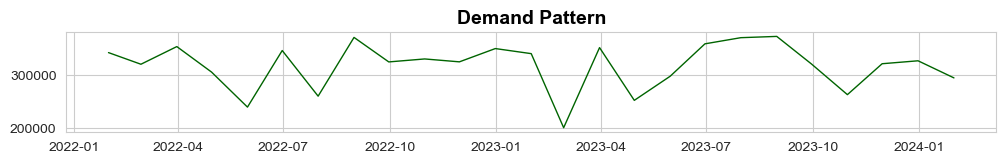

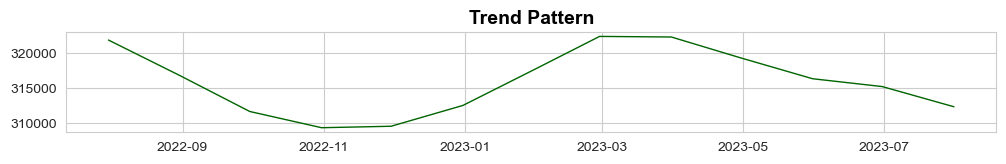

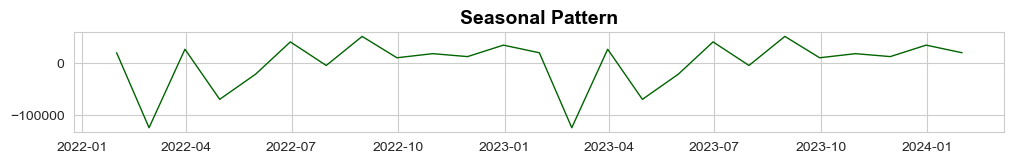

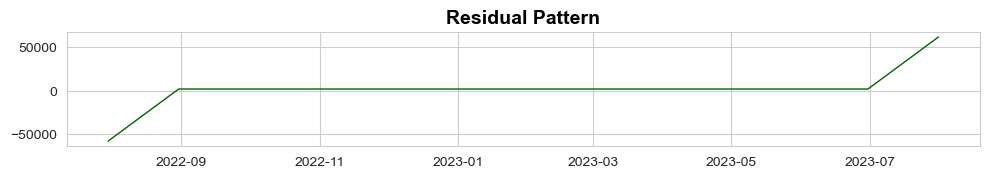

In [15]:
# let's decompose the trend,seasonality and noise
result=seasonal_decompose(monthly_demand,model='additive')
trend=result.trend
seasonality=result.seasonal
noise=result.resid

plt.figure(figsize=(12,6))
plt.subplot(411)
plt.plot(monthly_demand,color='darkgreen',linewidth=1)
plt.title('Demand Pattern',fontsize=14,fontweight='bold',color='black')
plt.show()

plt.figure(figsize=(12,6))
plt.subplot(412)
plt.plot(trend,label='Trend',color='darkgreen',linewidth=1)
plt.title('Trend Pattern',fontsize=14,fontweight='bold',color='black')
plt.show()

plt.figure(figsize=(12,6))
plt.subplot(413)
plt.plot(seasonality,color='darkgreen',linewidth=1)
plt.title('Seasonal Pattern',fontsize=14,fontweight='bold',color='black')
plt.show()

plt.figure(figsize=(10,6))
plt.subplot(413)
plt.plot(noise,color='darkgreen',linewidth=1)
plt.title('Residual Pattern',fontsize=14,fontweight='bold',color='black')

plt.tight_layout()
plt.show()

<h3 style="color :blue;">Observations</h3>
<p style="font-size:30px;color:black;">
<h5 style="color :blue;">Trend Pattern:</h5>There is a notable peak around March 2023 followed by a gradual decline,with a slight upward turn starting again in late 2023.<br><h5 style="color :blue;">Seasonal Pattern:</h5>This shows a very consistent,repeating 'M-shaped' cycle every few months. we can observe a sharp dip and recovery twice a year. In August Months we had high Demand. and in February Month we had dropdown of Demand.<br><h5 style="color :blue;">Residual Pattern:</h5>The residual is flat.but in late 2023 we have an unusual spike.</p>

<h3 style="color :blue;">Bottleneck of Residual spike in late 2023</h3>

In [16]:
residuals=result.resid.dropna()
mu=residuals.mean()
sigma=residuals.std()
threshold=2

#filtering and finding extreme spikes or drops.
outliers=residuals[(np.abs(residuals-mu)>(threshold*sigma))]
print('Unusual spikes detected at:')
print(outliers)

Unusual spikes detected at:
Date
2022-07-31   -58016.362847
2023-07-31    61653.012153
Name: resid, dtype: float64


In [17]:
for date in outliers.index:
    print(f" data for {date.strftime('%B %Y')}")
    month_data=df[(df.index.month==date.month)&(df.index.year==date.year)]
    print(month_data[['Demand','Promotion','Discount','Weather Condition','Competitor Pricing']].head(10))

 data for July 2022
            Demand  Promotion  Discount Weather Condition  Competitor Pricing
Date                                                                         
2022-07-01    94.0        0.0      10.0             Rainy               34.12
2022-07-01    71.0        0.0       5.0             Rainy               28.83
2022-07-01    21.0        0.0      10.0             Rainy               65.35
2022-07-01    64.0        0.0       5.0             Rainy               18.28
2022-07-01    63.0        0.0       0.0             Rainy               21.06
2022-07-01   112.0        0.0       5.0             Rainy               64.89
2022-07-01    25.0        0.0       5.0             Rainy               80.77
2022-07-01    50.0        0.0       0.0             Rainy               67.20
2022-07-01   162.0        1.0      15.0             Rainy              111.41
2022-07-01    75.0        1.0      10.0             Rainy               48.89
 data for July 2023
            Demand  Prom

<h3 style="color :blue;">The Evidence</h3>
<p style="font-size:30px;color:black;">July 2023:<br> we have two days where demand is 129 and 120. On those exact days, the discount was 20 and 10 and promotion was 1 and 0.<br>July-2022:<br>On sames days,demand was much lower and promotion was mostly 0.<br>Weather Factor:<br>Notice it was rainy in 2023 but cloudy in 2022.</p>

<h3 style="color :blue;">conclusion</h3>
<p style="font-size:30px;color:black;">The unusual spike is likely driven by changes in competitor pricing and weather conditions,possibly interacting with discount strategy.</p>

In [50]:
df.groupby('Product Id')['Units Ordered'].sum()

Product Id
P0001    358108.0
P0002    360432.0
P0003    343328.0
P0004    378642.0
P0005    353841.0
P0006    345177.0
P0007    382116.0
P0008    323019.0
P0009    377105.0
P0010    358063.0
P0011    333874.0
P0012    296953.0
P0013    378224.0
P0014    318869.0
P0015    337451.0
P0016    327793.0
P0017    295940.0
P0018    310585.0
P0019    313405.0
P0020    278756.0
Name: Units Ordered, dtype: float64

In [18]:
#Let's calculate the metrics
# Avg Demand
print('Average of Demand:')
print(df['Demand'].mean().round(2))

# std of demand
print('The Std of Demand:')
print(df['Demand'].std())

Average of Demand:
104.32
The Std of Demand:
46.965223184611936


In [19]:
#Let's do how the columns are impacted the demand
#promotion impact analysis on demand
promo_analysis=df.groupby('Promotion')['Demand'].mean()
print(promo_analysis)

Promotion
0.0     95.026254
1.0    123.268139
Name: Demand, dtype: float64


<h3 style="color :blue;">Observations</h3>
<p style="font-size:30px;color:black;">Running a promotion is giving us 30% increase in sales.<br>Inventory Management:-<br>During Promotion is active increase the inventory,and we won't affected by the holding cost for that extra inventory as there will be more demand.</p>

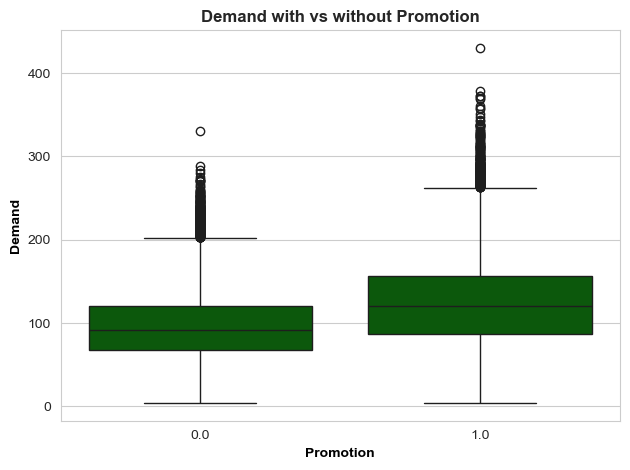

In [20]:
#visualizations
sns.set_style('whitegrid')
sns.boxplot(x='Promotion',y='Demand',data=df,color='darkgreen')
plt.title('Demand with vs without Promotion',fontweight='bold')
plt.xlabel('Promotion',fontweight='bold',color='black')
plt.ylabel('Demand',fontweight='bold',color='black')
plt.tight_layout()
plt.show()

In [21]:
#demand lift
promo_mean=promo_analysis[1]
no_promo_mean=promo_analysis[0]
lift=((promo_mean-no_promo_mean)/no_promo_mean)*100
print(f"Promotion increases demand by {lift:.2f}%")

Promotion increases demand by 29.72%


In [22]:
#weather impact Analysis
weather_analysis=df.groupby('Weather Condition')['Demand'].mean()
print(weather_analysis)

Weather Condition
Cloudy    105.405098
Rainy      95.106743
Snowy      94.045789
Sunny     115.164092
Name: Demand, dtype: float64


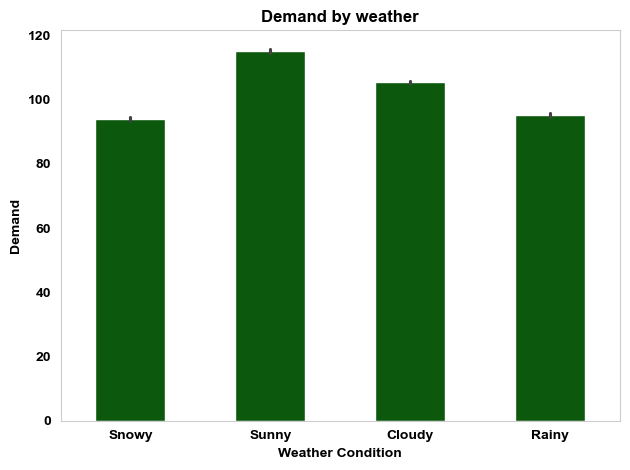

In [23]:
#visualization
sns.barplot(x='Weather Condition',y='Demand',data=df,color='darkgreen',width=0.5)
plt.title('Demand by weather',fontweight='bold',color='black')
plt.xlabel('Weather Condition',fontweight='bold',color='black')
plt.ylabel('Demand',fontweight='bold',color='black')
plt.xticks(color='black',fontweight='bold')
plt.yticks(color='black',fontweight='bold')
plt.grid(False)
plt.tight_layout()
plt.show()

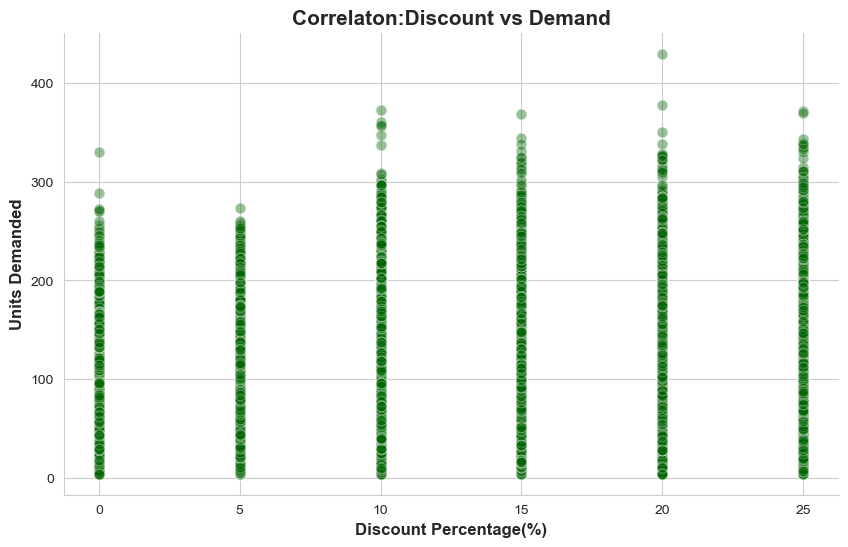

In [24]:
#discount impact
sns.set_style('whitegrid')
plt.figure(figsize=(10,6))
sns.scatterplot(x='Discount',y='Demand',data=df,color='darkgreen',alpha=0.4,
               s=60,edgecolor='w')
plt.title('Correlaton:Discount vs Demand',fontsize=15,fontweight='bold')
plt.xlabel('Discount Percentage(%)',fontsize=12,fontweight='bold')
plt.ylabel('Units Demanded',fontsize=12,fontweight='bold')

sns.despine()
plt.show()

In [25]:
correlation=df['Discount'].corr(df['Demand'])
print(correlation)

0.22468136427167087


<h3 style="color :blue;">Observations</h3>
<p style="font-size:30px;color:black;">As the correlation is positive but too weak,we can say the Discount is not impacting the Demand much.</p>

In [26]:
# epidemic categories
df['Epidemic'].value_counts()

Epidemic
0.0    60803
1.0    15200
Name: count, dtype: int64

In [27]:
# observing the epidemic on demand
epidemic_demand=df.groupby('Epidemic')['Demand'].mean()
epidemic_demand

Epidemic
0.0    112.855780
1.0     70.158816
Name: Demand, dtype: float64

<h3 style="color :blue;">Observations</h3>
<p style="font-size:30px;color:black;">There is High Demand without epidemic.<br> It represents roughly a 38% decrease in demand when an epidemic occurs.But keep in mind that there is 60803 are non-epidemic days.</p>

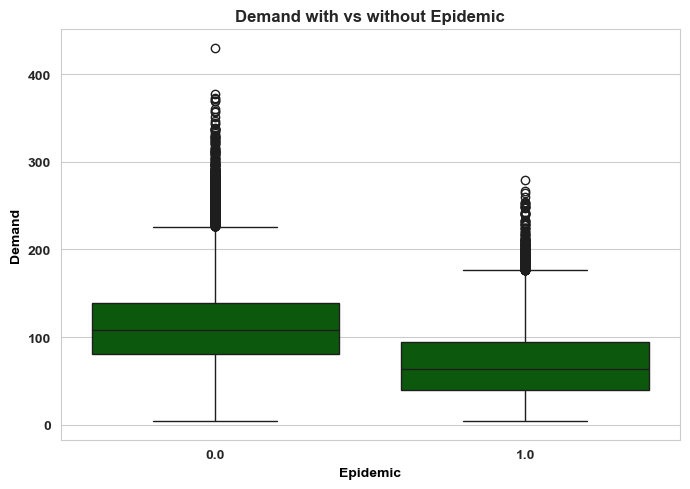

In [28]:
# plotting the epidemic and demand
plt.figure(figsize=(7,5))
sns.boxplot(x='Epidemic',y='Demand',data=df,color='darkgreen')
plt.title('Demand with vs without Epidemic',fontweight='bold')
plt.xlabel('Epidemic',fontweight='bold',color='black')
plt.ylabel('Demand',fontweight='bold',color='black')
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.tight_layout()
plt.show()

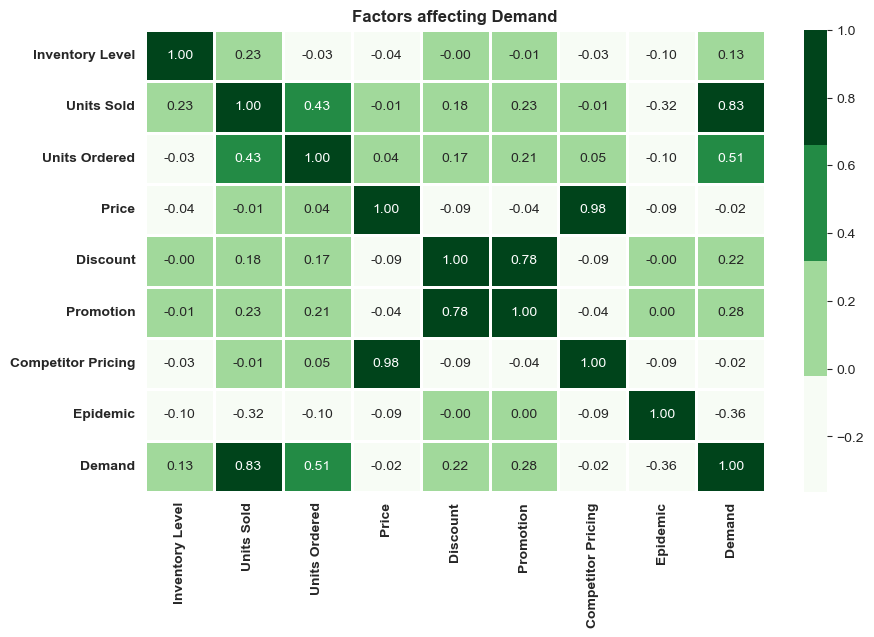

In [29]:
green_colors=['#f7fcf5','#a1d99b','#238b45','#00441b']
green_cmap=sns.color_palette(green_colors,as_cmap=True)
corr_matrix=df.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix,annot=True,cmap=green_cmap,fmt=".2f",linewidth=1,linecolor='white')
plt.title('Factors affecting Demand',fontweight='bold')
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.show()

<h3 style="color :blue;">Observations</h3>
<p style="font-size:30px;color:black;">Applying ABC analysis to find out the high,medium,and low demand products.</p>

In [30]:
#abc analysis for giving different service levels to different products
#aggragate the total demand per product
abc=df.groupby('Product Id')['Demand'].sum().reset_index()
abc.head(5)

,Product Id,Demand
0,P0001,416447.0
1,P0002,425853.0
2,P0003,395353.0
3,P0004,438505.0
4,P0005,408578.0


In [31]:
#sort by demand
abc=abc.sort_values(by='Demand',ascending=False)

In [32]:
#calculate cumulative values
abc['cum_demand']=abc['Demand'].cumsum()
abc['cum_perc']=abc['cum_demand']/abc['Demand'].sum()

In [33]:
#assign abc categories
def abc_class(x):
    if x<=0.80:
        return 'A'
    elif x<=0.95:
        return 'B'
    else:
        return 'C'
abc['ABC']=abc['cum_perc'].apply(abc_class)

In [34]:
abc.head(5)

,Product Id,Demand,cum_demand,cum_perc,ABC
8,P0009,450324.0,450324.0,0.056799,A
12,P0013,440895.0,891219.0,0.112409,A
3,P0004,438505.0,1329724.0,0.167717,A
6,P0007,437089.0,1766813.0,0.222847,A
1,P0002,425853.0,2192666.0,0.276559,A


In [35]:
# returning the  abc categories of products
abc['ABC'].value_counts()

ABC
A    15
B     3
C     2
Name: count, dtype: int64

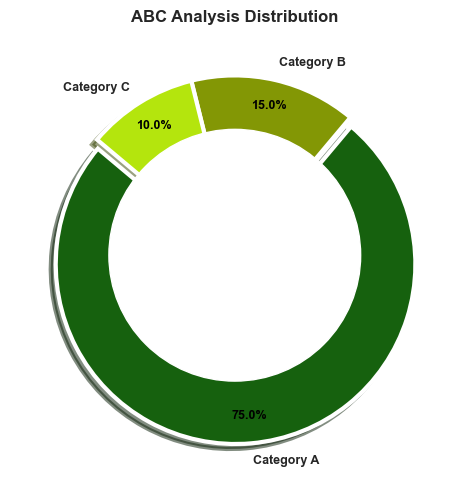

In [36]:
#visualize the category wise products.
labels=['Category A','Category B','Category C']
sizes=[75,15,10]
colors=['#16610E','#839705','#B4E50D']
explode=(0.05,0,0)
plt.figure(figsize=(5,5))
wedges,texts,autotexts=plt.pie(sizes,explode=explode,labels=labels,colors=colors,
        autopct='%1.1f%%',startangle=140,pctdistance=0.85,
        shadow=True,wedgeprops={'linewidth':3,'edgecolor':'white'})
centre_circle=plt.Circle((0,0),0.70,fc='white')
fig=plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title('ABC Analysis Distribution',fontweight='bold')
plt.setp(texts,size=9,weight='bold')
plt.setp(autotexts,size=9,weight='bold',color='black')
plt.tight_layout()
plt.show()

In [37]:
#Top A products
abc[abc['ABC']=='A']

,Product Id,Demand,cum_demand,cum_perc,ABC
8,P0009,450324.0,450324.0,0.056799,A
12,P0013,440895.0,891219.0,0.112409,A
3,P0004,438505.0,1329724.0,0.167717,A
6,P0007,437089.0,1766813.0,0.222847,A
1,P0002,425853.0,2192666.0,0.276559,A
9,P0010,422064.0,2614730.0,0.329794,A
0,P0001,416447.0,3031177.0,0.382320,A
5,P0006,409345.0,3440522.0,0.433950,A
4,P0005,408578.0,3849100.0,0.485484,A
7,P0008,396538.0,4245638.0,0.535499,A


In [38]:
#assign service level
def service_level(x):
    if x=='A':
        return 0.98
    elif x=='B':
        return 0.93
    else:
        return 0.85
abc['service_level']=abc['ABC'].apply(service_level)

In [39]:
#convert to z score
abc['z_score']=abc['service_level'].apply(lambda x:norm.ppf(x))

In [40]:
abc

,Product Id,Demand,cum_demand,cum_perc,ABC,service_level,z_score
8,P0009,450324.0,450324.0,0.056799,A,0.98,2.053749
12,P0013,440895.0,891219.0,0.112409,A,0.98,2.053749
3,P0004,438505.0,1329724.0,0.167717,A,0.98,2.053749
6,P0007,437089.0,1766813.0,0.222847,A,0.98,2.053749
1,P0002,425853.0,2192666.0,0.276559,A,0.98,2.053749
9,P0010,422064.0,2614730.0,0.329794,A,0.98,2.053749
0,P0001,416447.0,3031177.0,0.382320,A,0.98,2.053749
5,P0006,409345.0,3440522.0,0.433950,A,0.98,2.053749
4,P0005,408578.0,3849100.0,0.485484,A,0.98,2.053749
7,P0008,396538.0,4245638.0,0.535499,A,0.98,2.053749


In [41]:
#safety stock
#cal demand variability per product
demand_stats=(
    df.groupby('Product Id')['Demand'].agg(['mean','std']).reset_index()
)
demand_stats.head(5)

,Product Id,mean,std
0,P0001,109.591316,46.716978
1,P0002,112.066579,48.796185
2,P0003,104.012891,46.697381
3,P0004,115.396053,48.157642
4,P0005,107.520526,45.623828


In [42]:
CV=demand_stats['std']/demand_stats['mean']
CV

0     0.426284
1     0.435421
2     0.448958
3     0.417325
4     0.424327
5     0.445718
6     0.425467
7     0.439669
8     0.388906
9     0.442382
10    0.432639
11    0.457676
12    0.430402
13    0.463494
14    0.459519
15    0.460626
16    0.479621
17    0.460886
18    0.447080
19    0.470157
dtype: float64

<h3 style="color :blue;">Observations</h3>
<p style="font-size:30px;color:black;">1.The coefficient of variability of demand is <0.5 for all products. It means the demand of the products can be stable and predictable.<br>2.As CV<0.5,and demand is predictable so we don't need a large buffer of inventory to prevent stockouts. This can reduce Inventory Cost.</p>

In [43]:
#merge with abc table
inventory=pd.merge(abc,demand_stats,on='Product Id')
inventory.head(5)

,Product Id,Demand,cum_demand,cum_perc,ABC,service_level,z_score,mean,std
0,P0009,450324.0,450324.0,0.056799,A,0.98,2.053749,118.506316,46.087811
1,P0013,440895.0,891219.0,0.112409,A,0.98,2.053749,116.025000,49.937341
2,P0004,438505.0,1329724.0,0.167717,A,0.98,2.053749,115.396053,48.157642
3,P0007,437089.0,1766813.0,0.222847,A,0.98,2.053749,115.023421,48.938656
4,P0002,425853.0,2192666.0,0.276559,A,0.98,2.053749,112.066579,48.796185


In [44]:
#assume lead time
lead_time=7 #days
#calculate safety stock
inventory['safety_stock']=np.ceil(
inventory['z_score']*inventory['std']*np.sqrt(lead_time)
)

In [45]:
inventory

,Product Id,Demand,cum_demand,cum_perc,ABC,service_level,z_score,mean,std,safety_stock
0,P0009,450324.0,450324.0,0.056799,A,0.98,2.053749,118.506316,46.087811,251.0
1,P0013,440895.0,891219.0,0.112409,A,0.98,2.053749,116.025000,49.937341,272.0
2,P0004,438505.0,1329724.0,0.167717,A,0.98,2.053749,115.396053,48.157642,262.0
3,P0007,437089.0,1766813.0,0.222847,A,0.98,2.053749,115.023421,48.938656,266.0
4,P0002,425853.0,2192666.0,0.276559,A,0.98,2.053749,112.066579,48.796185,266.0
5,P0010,422064.0,2614730.0,0.329794,A,0.98,2.053749,111.069474,49.135104,267.0
6,P0001,416447.0,3031177.0,0.382320,A,0.98,2.053749,109.591316,46.716978,254.0
7,P0006,409345.0,3440522.0,0.433950,A,0.98,2.053749,107.722368,48.013768,261.0
8,P0005,408578.0,3849100.0,0.485484,A,0.98,2.053749,107.520526,45.623828,248.0
9,P0008,396538.0,4245638.0,0.535499,A,0.98,2.053749,104.352105,45.880359,250.0


<h3 style="color :blue;">Observations</h3>
<p style="font-size:30px;color:black;">The higher z_valued products should be maintained high safety stock. They are differ in calculated safety stock because of demand volatility.</p>

In [46]:
#reorder points
inventory['rop']=np.ceil(
    inventory['mean']*lead_time+inventory['safety_stock']
)

In [47]:
inventory.head(10)

,Product Id,Demand,cum_demand,cum_perc,ABC,service_level,z_score,mean,std,safety_stock,rop
0,P0009,450324.0,450324.0,0.056799,A,0.98,2.053749,118.506316,46.087811,251.0,1081.0
1,P0013,440895.0,891219.0,0.112409,A,0.98,2.053749,116.025000,49.937341,272.0,1085.0
2,P0004,438505.0,1329724.0,0.167717,A,0.98,2.053749,115.396053,48.157642,262.0,1070.0
3,P0007,437089.0,1766813.0,0.222847,A,0.98,2.053749,115.023421,48.938656,266.0,1072.0
4,P0002,425853.0,2192666.0,0.276559,A,0.98,2.053749,112.066579,48.796185,266.0,1051.0
5,P0010,422064.0,2614730.0,0.329794,A,0.98,2.053749,111.069474,49.135104,267.0,1045.0
6,P0001,416447.0,3031177.0,0.382320,A,0.98,2.053749,109.591316,46.716978,254.0,1022.0
7,P0006,409345.0,3440522.0,0.433950,A,0.98,2.053749,107.722368,48.013768,261.0,1016.0
8,P0005,408578.0,3849100.0,0.485484,A,0.98,2.053749,107.520526,45.623828,248.0,1001.0
9,P0008,396538.0,4245638.0,0.535499,A,0.98,2.053749,104.352105,45.880359,250.0,981.0


In [48]:
#filter only A items
mask_a=inventory['ABC']=='A'
#rank the A category products so that we could extract more critical products. 
inventory.loc[mask_a,'sub_category']=inventory[mask_a]['Demand'].rank(pct=True).apply(lambda x:'A1' if x>0.6 else'A2')
#assign new service levels.
def update_service_level(row):
    if row['sub_category']=='A1':return 0.98
    if row['sub_category']=='A2':return 0.95
    if row['ABC']=='B':return 0.88
    return 0.85
inventory['service_level']=inventory.apply(update_service_level,axis=1)

from scipy.stats import norm
inventory['Z']=inventory['service_level'].apply(lambda x:norm.ppf(x))
inventory['safety_stock']=inventory['Z']*inventory['std']*np.sqrt(lead_time)

In [49]:
inventory

,Product Id,Demand,cum_demand,cum_perc,ABC,service_level,z_score,mean,std,safety_stock,rop,sub_category,Z
0,P0009,450324.0,450324.0,0.056799,A,0.98,2.053749,118.506316,46.087811,250.427746,1081.0,A1,2.053749
1,P0013,440895.0,891219.0,0.112409,A,0.98,2.053749,116.025000,49.937341,271.344971,1085.0,A1,2.053749
2,P0004,438505.0,1329724.0,0.167717,A,0.98,2.053749,115.396053,48.157642,261.674605,1070.0,A1,2.053749
3,P0007,437089.0,1766813.0,0.222847,A,0.98,2.053749,115.023421,48.938656,265.918411,1072.0,A1,2.053749
4,P0002,425853.0,2192666.0,0.276559,A,0.98,2.053749,112.066579,48.796185,265.144264,1051.0,A1,2.053749
5,P0010,422064.0,2614730.0,0.329794,A,0.98,2.053749,111.069474,49.135104,266.985848,1045.0,A1,2.053749
6,P0001,416447.0,3031177.0,0.382320,A,0.95,2.053749,109.591316,46.716978,203.306383,1022.0,A2,1.644854
7,P0006,409345.0,3440522.0,0.433950,A,0.95,2.053749,107.722368,48.013768,208.949853,1016.0,A2,1.644854
8,P0005,408578.0,3849100.0,0.485484,A,0.95,2.053749,107.520526,45.623828,198.549134,1001.0,A2,1.644854
9,P0008,396538.0,4245638.0,0.535499,A,0.95,2.053749,104.352105,45.880359,199.665525,981.0,A2,1.644854


<h3 style="color :blue;">Observations</h3>
<p style="font-size:30px;color:black;">Here we had 15 critical products out of 20 total products. To maintain more safety stock for all those products can take more stock and cost. <br> so we again filtered the most critical products from the A category products.<br> And we have Top 6 such products that need more safety stock. so out of 15 products we need to maintain more safety stock for 6 products to optimize the safety stock.</p>

<h3 style="color :blue;">Recommendations</h3>
<p style="font-size:30px;color:black;">1.By our Analysis the A1 category products should be maintained more safety stock. <br>2.There are 15 critical products that should maintain more safety stock,but we extracted most critical products from that to optimize the safety stock.<br>3.If the Lead time is less,then we could optimize some more safety stock.</p>